# Completion time 

### Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load preprocessed Data

In [ ]:
# =======================================================
# 1) CONFIG AND LOAD PREPROCESSED RAW DATA
# =======================================================
# Goal:
# Load the preprocessed raw eye-tracking/task data as the basis
# for computing trial-level raw completion time.
#
# This notebook focuses on simply completion time,
# not object-gaze measures.

from pathlib import Path

import numpy as np
import pandas as pd

# -------------------------------------------------------
# Project paths
# -------------------------------------------------------

SCRIPT_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
PROJECT_ROOT = SCRIPT_DIR.parent

DATA_RAW_DIR = PROJECT_ROOT / "Data" / "Raw"
DATA_PROCESSED_DIR = PROJECT_ROOT / "Data" / "Processed"

RESULT_TABLES_DIR = PROJECT_ROOT / "Results" / "Tables"
RESULT_PLOTS_DIR = PROJECT_ROOT / "Results" / "Plots"

DATA_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
RESULT_TABLES_DIR.mkdir(parents=True, exist_ok=True)
RESULT_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------------
# Analysis settings
# -------------------------------------------------------

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

TRIAL_COLS = [
    "participant_id",
    "model_name",
    "condition"
]

FORCE_TIME_UNIT = "ms"

# -------------------------------------------------------
# Load preprocessed raw data
# -------------------------------------------------------

PREPROCESSED_CSV = DATA_PROCESSED_DIR / "preprocessed_raw_all.csv"

raw_all = pd.read_csv(PREPROCESSED_CSV, low_memory=False)

print("PROJECT_ROOT       :", PROJECT_ROOT)
print("DATA_PROCESSED_DIR :", DATA_PROCESSED_DIR)
print("RESULT_TABLES_DIR  :", RESULT_TABLES_DIR)
print("RESULT_PLOTS_DIR   :", RESULT_PLOTS_DIR)
print("raw_all shape      :", raw_all.shape)

display(raw_all.head())

PROJECT_ROOT       : /Users/luise/Library/CloudStorage/OneDrive-Persönlich/Bachelorarbeit
DATA_PROCESSED_DIR : /Users/luise/Library/CloudStorage/OneDrive-Persönlich/Bachelorarbeit/Data/Processed
RESULT_TABLES_DIR  : /Users/luise/Library/CloudStorage/OneDrive-Persönlich/Bachelorarbeit/Results/Tables
RESULT_PLOTS_DIR   : /Users/luise/Library/CloudStorage/OneDrive-Persönlich/Bachelorarbeit/Results/Plots
raw_all shape      : (4680329, 58)


,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,left_eye_calibration_quality,right_eye_calibration_quality,UID,recording_date,source_file,is_valid_model,AF,complexity,condition,hit_obj_name_corr
0,1000002773811334400,1754658861466,5.185122,0.913979,257894,0.0,Valid,0.199822,-0.038434,0.979078,...,Unknown,Unknown,1,2025-08-08,01_ET_Data_2025-08-08.csv,False,Unknown,NaN,NaN,Floor
1,1000002773816336100,1754658861467,5.185122,0.908018,257895,0.0,Valid,0.227848,-0.056482,0.972057,...,Unknown,Unknown,1,2025-08-08,01_ET_Data_2025-08-08.csv,False,Unknown,NaN,NaN,Floor
2,1000002773821337800,1754658861467,5.185122,0.915157,257896,0.0,Valid,0.254252,-0.073261,0.964359,...,Unknown,Unknown,1,2025-08-08,01_ET_Data_2025-08-08.csv,False,Unknown,NaN,NaN,Floor
3,1000002773826339500,1754658861467,5.185122,0.965864,257897,0.0,Valid,0.278826,-0.091104,0.956010,...,Unknown,Unknown,1,2025-08-08,01_ET_Data_2025-08-08.csv,False,Unknown,NaN,NaN,Floor
4,1000002773831339600,1754658861467,5.185122,1.029571,257898,0.0,Valid,0.302282,-0.109190,0.946944,...,Unknown,Unknown,1,2025-08-08,01_ET_Data_2025-08-08.csv,False,Unknown,NaN,NaN,Floor


### which columns existed in raw_all

In [3]:
# =======================================================
# 2) INSPECT ALL COLUMNS IN raw_all
# =======================================================
# Goal:
# Check which columns are available before building
# the completion-time dataframe.

print("raw_all shape:")
print(raw_all.shape)

print("\nNumber of columns:")
print(len(raw_all.columns))

print("\nAll column names:")
for i, col in enumerate(raw_all.columns):
    print(f"{i:02d}: {col}")

raw_all shape:
(4680329, 58)

Number of columns:
58

All column names:
00: gaze_capture_time
01: raw_timestamp
02: relative_to_unix_epoch_timestamp
03: focus_distance
04: frame_number
05: stability
06: status
07: gaze_forward_x
08: gaze_forward_y
09: gaze_forward_z
10: gaze_origin_x
11: gaze_origin_y
12: gaze_origin_z
13: left_forward_x
14: left_forward_y
15: left_forward_z
16: left_origin_x
17: left_origin_y
18: left_origin_z
19: left_status
20: left_pupil_diameter
21: left_iris_diameter
22: left_pupil_iris_ratio
23: left_eye_openness
24: right_forward_x
25: right_forward_y
26: right_forward_z
27: right_origin_x
28: right_origin_y
29: right_origin_z
30: right_status
31: right_pupil_diameter
32: right_iris_diameter
33: right_pupil_iris_ratio
34: right_eye_openness
35: inter_pupillary_distance
36: hmd_position_x
37: hmd_position_y
38: hmd_position_z
39: hmd_rotation_x
40: hmd_rotation_y
41: hmd_rotation_z
42: hmd_rotation_w
43: model_name
44: is_building_model
45: hit_obj_name
46: calib

## pick relevant columns for completion time of raw_all

In [4]:
# =======================================================
# 4a) SELECT RELEVANT COLUMNS FOR COMPLETION-TIME ANALYSIS
# =======================================================
# Goal:
# Create a smaller working dataframe with only the columns needed
# for computing raw trial completion time.

COMPLETION_INPUT_COLS = [
    "UID",
    "model_name",
    "condition",
    "is_valid_model",
    "is_building_model",
    "raw_timestamp"
]

missing_cols = [
    col for col in COMPLETION_INPUT_COLS
    if col not in raw_all.columns
]

print("Missing columns:")
print(missing_cols)

completion_sequence = raw_all[COMPLETION_INPUT_COLS].copy()

print("\ncompletion_sequence shape:")
print(completion_sequence.shape)

print("\ncompletion_sequence columns:")
print(completion_sequence.columns.tolist())

display(completion_sequence.head(20))

Missing columns:
[]

completion_sequence shape:
(4680329, 6)

completion_sequence columns:
['UID', 'model_name', 'condition', 'is_valid_model', 'is_building_model', 'raw_timestamp']


,UID,model_name,condition,is_valid_model,is_building_model,raw_timestamp
0,1,NaN,NaN,False,False,1754658861466
1,1,NaN,NaN,False,False,1754658861467
2,1,NaN,NaN,False,False,1754658861467
3,1,NaN,NaN,False,False,1754658861467
4,1,NaN,NaN,False,False,1754658861467
5,1,NaN,NaN,False,False,1754658861467
6,1,NaN,NaN,False,False,1754658861468
7,1,NaN,NaN,False,False,1754658861468
8,1,NaN,NaN,False,False,1754658861468
9,1,NaN,NaN,False,False,1754658861468


In [5]:
# =======================================================
# 4b) STANDARDIZE PARTICIPANT IDENTIFIER
# =======================================================
# Goal:
# Rename UID to participant_id only in the completion-time working dataframe.
# raw_all remains unchanged.

completion_sequence = completion_sequence.rename(columns={
    "UID": "participant_id"
})

print("raw_all still has UID:")
print("UID" in raw_all.columns)

print("\nraw_all has participant_id:")
print("participant_id" in raw_all.columns)

print("\ncompletion_sequence has participant_id:")
print("participant_id" in completion_sequence.columns)

print("\ncompletion_sequence still has UID:")
print("UID" in completion_sequence.columns)

print("\ncompletion_sequence columns:")
print(completion_sequence.columns.tolist())

print("\nExample participant IDs:")
display(
    completion_sequence["participant_id"]
    .dropna()
    .astype(str)
    .drop_duplicates()
    .head(20)
)

display(completion_sequence.head(20))

raw_all still has UID:
True

raw_all has participant_id:
False

completion_sequence has participant_id:
True

completion_sequence still has UID:
False

completion_sequence columns:
['participant_id', 'model_name', 'condition', 'is_valid_model', 'is_building_model', 'raw_timestamp']

Example participant IDs:


0           1
472291      2
1052510     3
1606518     4
2002190     5
2399620     6
3063713     7
3459842     8
3954635     9
4306042    10
Name: participant_id, dtype: object

,participant_id,model_name,condition,is_valid_model,is_building_model,raw_timestamp
0,1,NaN,NaN,False,False,1754658861466
1,1,NaN,NaN,False,False,1754658861467
2,1,NaN,NaN,False,False,1754658861467
3,1,NaN,NaN,False,False,1754658861467
4,1,NaN,NaN,False,False,1754658861467
5,1,NaN,NaN,False,False,1754658861467
6,1,NaN,NaN,False,False,1754658861468
7,1,NaN,NaN,False,False,1754658861468
8,1,NaN,NaN,False,False,1754658861468
9,1,NaN,NaN,False,False,1754658861468



### - Wie ist is_valid_model codiert?
### - Wie ist is_building_model codiert?
### - Sind raw_timestamp wirklich numerisch?
### - Gibt es nur die drei Conditions?
### - Sehen model_name und participant_id sauber aus?

In [7]:
# =======================================================
# 5) INSPECT CODING AND DATA TYPES
# =======================================================
# Goal:
# Check how the key variables are coded before filtering
# and computing raw completion time.

print("completion_sequence shape:")
print(completion_sequence.shape)

print("\nColumn dtypes:")
display(completion_sequence.dtypes)

print("\nis_valid_model values:")
display(
    completion_sequence["is_valid_model"]
    .value_counts(dropna=False)
)

print("\nis_building_model values:")
display(
    completion_sequence["is_building_model"]
    .value_counts(dropna=False)
)

print("\nCondition counts:")
display(
    completion_sequence["condition"]
    .value_counts(dropna=False)
)

print("\nNumber of unique participants:")
print(completion_sequence["participant_id"].nunique(dropna=True))

print("\nNumber of unique model names:")
print(completion_sequence["model_name"].nunique(dropna=True))

print("\nraw_timestamp summary:")
display(
    completion_sequence["raw_timestamp"]
    .describe()
)

completion_sequence shape:
(4680329, 6)

Column dtypes:


participant_id        int64
model_name           object
condition            object
is_valid_model         bool
is_building_model      bool
raw_timestamp         int64
dtype: object


is_valid_model values:


is_valid_model
True     2631218
False    2049111
Name: count, dtype: int64


is_building_model values:


is_building_model
True     3288328
False    1392001
Name: count, dtype: int64


Condition counts:


condition
NaN           2049111
2.0s delay     936929
0.7s delay     847298
constant       846991
Name: count, dtype: int64


Number of unique participants:
10

Number of unique model names:
19

raw_timestamp summary:


count    4.680329e+06
mean     1.755701e+12
std      6.505062e+08
min      1.754659e+12
25%      1.755159e+12
50%      1.755529e+12
75%      1.756393e+12
max      1.756802e+12
Name: raw_timestamp, dtype: float64

In [8]:
pd.crosstab(
    completion_sequence["is_valid_model"],
    completion_sequence["is_building_model"]
)

is_building_model,False,True
is_valid_model,,
False,1363996,685115
True,28005,2603213


### filter just valid rows

In [9]:
# =======================================================
# 7) KEEP VALID BUILDING-PHASE ROWS
# =======================================================

completion_sequence_valid = completion_sequence[
    (completion_sequence["is_valid_model"] == True)
    &
    (completion_sequence["is_building_model"] == True)
].copy()

print("completion_sequence_valid shape:")
print(completion_sequence_valid.shape)

print("\nNumber of valid building-phase trials:")
print(
    completion_sequence_valid[TRIAL_COLS]
    .drop_duplicates()
    .shape[0]
)

print("\nValid building-phase trials per condition:")
display(
    completion_sequence_valid[TRIAL_COLS]
    .drop_duplicates()["condition"]
    .value_counts()
    .reindex(COND_ORDER)
)

completion_sequence_valid shape:
(2603213, 6)

Number of valid building-phase trials:
180

Valid building-phase trials per condition:


condition
constant      60
0.7s delay    60
2.0s delay    60
Name: count, dtype: int64

In [10]:
# =======================================================
# 8) COMPUTE RAW COMPLETION TIME PER TRIAL
# =======================================================
# Goal:
# Build one row per valid experimental model trial during the active
# building phase.
#
# Raw completion time is computed from raw timestamps:
# max(raw_timestamp) - min(raw_timestamp)
#
# Trial definition:
# participant_id + model_name + condition

raw_completion_time = (
    completion_sequence_valid
    .groupby(TRIAL_COLS, as_index=False)
    .agg(
        trial_start_timestamp=("raw_timestamp", "min"),
        trial_end_timestamp=("raw_timestamp", "max"),
        n_raw_samples=("raw_timestamp", "size")
    )
)

raw_completion_time["raw_completion_time_s"] = (
    raw_completion_time["trial_end_timestamp"]
    -
    raw_completion_time["trial_start_timestamp"]
) / 1000

raw_completion_time["condition"] = pd.Categorical(
    raw_completion_time["condition"],
    categories=COND_ORDER,
    ordered=True
)

raw_completion_time = (
    raw_completion_time
    .sort_values(TRIAL_COLS)
    .reset_index(drop=True)
)

print("raw_completion_time shape:")
print(raw_completion_time.shape)

display(raw_completion_time.head(20))

print("\nTrials per condition:")
display(
    raw_completion_time["condition"]
    .value_counts()
    .reindex(COND_ORDER)
)

print("\nRaw completion time summary by condition:")
display(
    raw_completion_time
    .groupby("condition", observed=False)["raw_completion_time_s"]
    .describe()
    .round(2)
)

raw_completion_time shape:
(180, 7)


,participant_id,model_name,condition,trial_start_timestamp,trial_end_timestamp,n_raw_samples,raw_completion_time_s
0,1,C1M1F,0.7s delay,1754660317699,1754660388441,14065,70.742
1,1,C1M2A,constant,1754659655491,1754659703811,9553,48.320
2,1,C1M3F,constant,1754659508492,1754659558342,9898,49.850
3,1,C1M4A,0.7s delay,1754660406043,1754660447663,8171,41.620
4,1,C1M5F,2.0s delay,1754661545371,1754661579359,6609,33.988
5,1,C1M6A,2.0s delay,1754661493093,1754661527069,6563,33.976
6,1,C2M1F,2.0s delay,1754661304895,1754661371259,12801,66.364
7,1,C2M2A,2.0s delay,1754661392683,1754661471302,15190,78.619
8,1,C2M3F,0.7s delay,1754659998622,1754660061998,12417,63.376
9,1,C2M4A,0.7s delay,1754660228532,1754660291920,12391,63.388



Trials per condition:


condition
constant      60
0.7s delay    60
2.0s delay    60
Name: count, dtype: int64


Raw completion time summary by condition:


,count,mean,std,min,25%,50%,75%,max
condition,,,,,,,,
constant,60.0,72.85,45.36,20.02,38.82,56.04,101.96,215.38
0.7s delay,60.0,72.56,50.81,17.86,30.60,63.38,83.48,246.63
2.0s delay,60.0,80.01,63.05,13.76,33.98,65.78,95.46,342.82


/var/folders/7k/2zmy2sns485034b8qp7j11440000gn/T/ipykernel_82737/2648356668.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


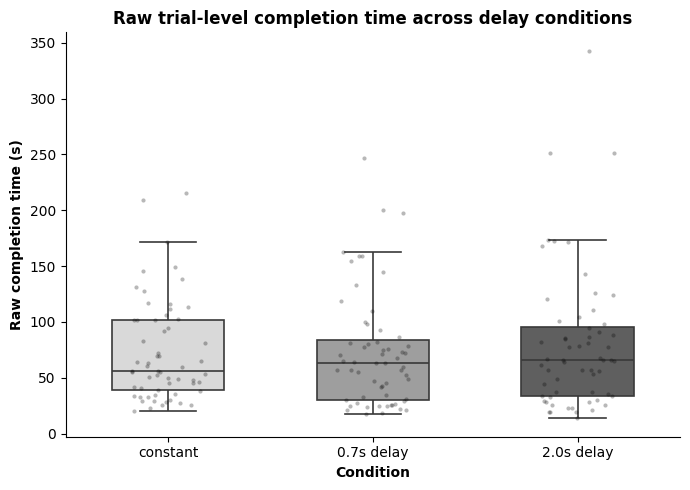

In [11]:
# =======================================================
# 9) PLOT RAW COMPLETION TIME BY CONDITION
# =======================================================
# Goal:
# Visualize raw trial-level completion time across conditions.
#
# Each dot = one valid experimental model trial during the active building phase.
# Boxplot = distribution of raw trial-level completion times.
#
# No participant averaging.
# No delay correction.

import matplotlib.pyplot as plt
import seaborn as sns

COND_COLORS = {
    "constant": "#d9d9d9",
    "0.7s delay": "#9e9e9e",
    "2.0s delay": "#5f5f5f"
}

plot_raw_completion = raw_completion_time.copy()

plot_raw_completion["condition"] = (
    plot_raw_completion["condition"]
    .astype(str)
)

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=plot_raw_completion,
    x="condition",
    y="raw_completion_time_s",
    order=COND_ORDER,
    palette=COND_COLORS,
    showfliers=False,
    width=0.55,
    linewidth=1.2
)

sns.stripplot(
    data=plot_raw_completion,
    x="condition",
    y="raw_completion_time_s",
    order=COND_ORDER,
    color="black",
    alpha=0.28,
    size=3,
    jitter=0.18
)

plt.xlabel("Condition", fontweight="bold")
plt.ylabel("Raw completion time (s)", fontweight="bold")
plt.title(
    "Raw trial-level completion time across delay conditions",
    fontweight="bold"
)

sns.despine()
plt.tight_layout()
plt.show()

### build participant level data: 

In [13]:
# =======================================================
# 10) BUILD PARTICIPANT-LEVEL RAW COMPLETION TIME
# =======================================================
# Goal:
# Compute each participant's mean raw completion time per condition.
#
# Input:
# raw_completion_time
#
# Output:
# participant_raw_completion
#
# Each row = one participant × condition

participant_raw_completion = (
    raw_completion_time
    .assign(condition=lambda df: df["condition"].astype(str))
    .groupby(["participant_id", "condition"], as_index=False)
    .agg(
        mean_raw_completion_time_s=("raw_completion_time_s", "mean"),
        n_trials=("model_name", "nunique")
    )
)

participant_raw_completion["condition"] = pd.Categorical(
    participant_raw_completion["condition"],
    categories=COND_ORDER,
    ordered=True
)

participant_raw_completion = (
    participant_raw_completion
    .sort_values(["participant_id", "condition"])
    .reset_index(drop=True)
)

print("participant_raw_completion shape:")
print(participant_raw_completion.shape)

display(participant_raw_completion.head(30))

print("\nParticipants per condition:")
display(
    participant_raw_completion
    .groupby("condition", observed=False)["participant_id"]
    .nunique()
)

print("\nParticipant-level raw completion time summary:")
display(
    participant_raw_completion
    .groupby("condition", observed=False)["mean_raw_completion_time_s"]
    .describe()
    .round(2)
)

participant_raw_completion shape:
(30, 4)


,participant_id,condition,mean_raw_completion_time_s,n_trials
0,1,constant,91.857833,6
1,1,0.7s delay,86.062333,6
2,1,2.0s delay,70.766167,6
3,2,constant,80.272000,6
4,2,0.7s delay,91.485167,6
5,2,2.0s delay,97.122500,6
6,3,constant,80.361667,6
7,3,0.7s delay,74.210833,6
8,3,2.0s delay,74.929833,6
9,4,constant,65.979667,6



Participants per condition:


condition
constant      10
0.7s delay    10
2.0s delay    10
Name: participant_id, dtype: int64


Participant-level raw completion time summary:


,count,mean,std,min,25%,50%,75%,max
condition,,,,,,,,
constant,10.0,72.85,15.92,50.48,60.25,72.37,80.34,100.47
0.7s delay,10.0,72.56,21.06,46.05,55.36,71.25,83.74,114.92
2.0s delay,10.0,80.01,25.51,48.79,66.08,72.85,91.18,138.32


### build group mean

In [14]:
# =======================================================
# 11) BUILD GROUP SUMMARY OF RAW COMPLETION TIME
# =======================================================
# Goal:
# Compute group mean and SE across participant means.
#
# Input:
# participant_raw_completion
#
# Output:
# group_raw_completion

group_raw_completion = (
    participant_raw_completion
    .groupby("condition", observed=False, as_index=False)
    .agg(
        group_mean_raw_completion_time_s=("mean_raw_completion_time_s", "mean"),
        sd_raw_completion_time_s=("mean_raw_completion_time_s", "std"),
        n_participants=("participant_id", "nunique")
    )
)

group_raw_completion["se_raw_completion_time_s"] = (
    group_raw_completion["sd_raw_completion_time_s"] /
    np.sqrt(group_raw_completion["n_participants"])
)

group_raw_completion["condition"] = pd.Categorical(
    group_raw_completion["condition"],
    categories=COND_ORDER,
    ordered=True
)

group_raw_completion = (
    group_raw_completion
    .sort_values("condition")
    .reset_index(drop=True)
)

print("group_raw_completion:")
display(group_raw_completion.round(2))

group_raw_completion:


,condition,group_mean_raw_completion_time_s,sd_raw_completion_time_s,n_participants,se_raw_completion_time_s
0,constant,72.85,15.92,10,5.03
1,0.7s delay,72.56,21.06,10,6.66
2,2.0s delay,80.01,25.51,10,8.07


### plot

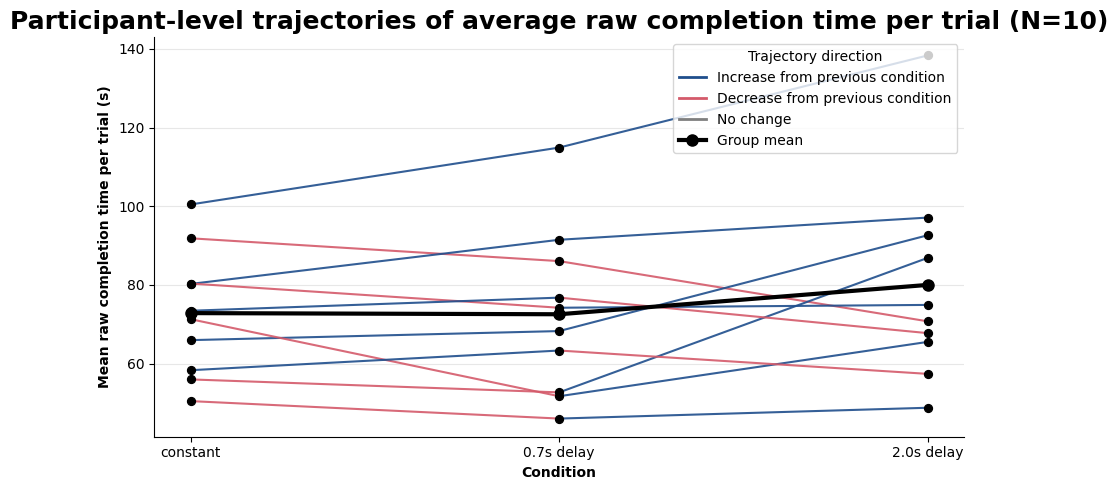

In [15]:
# =======================================================
# 12) PLOT PARTICIPANT-LEVEL TRAJECTORIES OF RAW COMPLETION TIME
# =======================================================
# Goal:
# Show participant-level trajectories of mean raw completion time
# across the three delay conditions.
#
# Thin colored lines = individual participant trajectories
#   blue: increase from previous condition
#   red: decrease from previous condition
#   gray: no change
#
# Thick black line = group mean across participant means

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plot_participant_raw = participant_raw_completion.copy()
plot_group_raw = group_raw_completion.copy()

plot_participant_raw["condition"] = (
    plot_participant_raw["condition"]
    .astype(str)
)

plot_group_raw["condition"] = (
    plot_group_raw["condition"]
    .astype(str)
)

x_positions = {
    "constant": 0,
    "0.7s delay": 1,
    "2.0s delay": 2
}

N_PARTICIPANTS = plot_participant_raw["participant_id"].nunique()

# Colors
INCREASE_COLOR = "#1f4e8c"   # blue
DECREASE_COLOR = "#d45a6a"   # red/pink
NO_CHANGE_COLOR = "#7f7f7f"  # gray

fig, ax = plt.subplots(figsize=(9, 5))

# -------------------------------------------------------
# Individual participant trajectories
# -------------------------------------------------------
for participant_id, sub in plot_participant_raw.groupby("participant_id"):

    sub = (
        sub
        .set_index("condition")
        .reindex(COND_ORDER)
        .reset_index()
    )

    x = [x_positions[c] for c in sub["condition"]]
    y = sub["mean_raw_completion_time_s"].values

    # Participant points
    ax.scatter(
        x,
        y,
        color="black",
        s=32,
        zorder=3
    )

    # Line segments between conditions
    for i in range(len(COND_ORDER) - 1):

        if y[i + 1] > y[i]:
            segment_color = INCREASE_COLOR
        elif y[i + 1] < y[i]:
            segment_color = DECREASE_COLOR
        else:
            segment_color = NO_CHANGE_COLOR

        ax.plot(
            [x[i], x[i + 1]],
            [y[i], y[i + 1]],
            color=segment_color,
            linewidth=1.5,
            alpha=0.9,
            zorder=2
        )

# -------------------------------------------------------
# Group mean trajectory
# -------------------------------------------------------
group_plot = (
    plot_group_raw
    .set_index("condition")
    .reindex(COND_ORDER)
    .reset_index()
)

group_x = [x_positions[c] for c in group_plot["condition"]]
group_y = group_plot["group_mean_raw_completion_time_s"].values

ax.plot(
    group_x,
    group_y,
    color="black",
    linewidth=3,
    marker="o",
    markersize=8,
    zorder=5,
    label="Group mean"
)

# -------------------------------------------------------
# Formatting
# -------------------------------------------------------
ax.set_xticks(list(x_positions.values()))
ax.set_xticklabels(COND_ORDER)

ax.set_xlabel("Condition", fontweight="bold")
ax.set_ylabel("Mean raw completion time per trial (s)", fontweight="bold")

ax.set_title(
    f"Participant-level trajectories of average raw completion time per trial (N={N_PARTICIPANTS})",
    fontweight="bold",
    fontsize=18
)

ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

legend_elements = [
    Line2D([0], [0], color=INCREASE_COLOR, lw=2, label="Increase from previous condition"),
    Line2D([0], [0], color=DECREASE_COLOR, lw=2, label="Decrease from previous condition"),
    Line2D([0], [0], color=NO_CHANGE_COLOR, lw=2, label="No change"),
    Line2D([0], [0], color="black", lw=3, marker="o", markersize=8, label="Group mean")
]

ax.legend(
    handles=legend_elements,
    title="Trajectory direction",
    frameon=True,
    loc="upper right"
)

plt.tight_layout()
plt.show()
plt.close(fig)

#### more beautiful plot

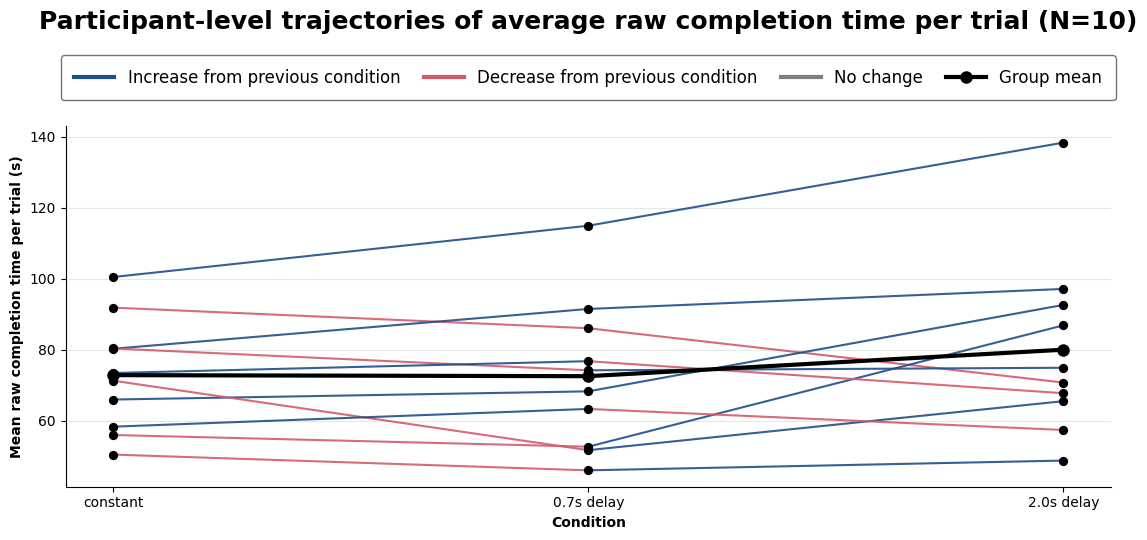

In [36]:
# =======================================================
# 12) PLOT PARTICIPANT-LEVEL TRAJECTORIES OF RAW COMPLETION TIME
# =======================================================
# Goal:
# Show participant-level trajectories of mean raw completion time
# across the three delay conditions.
#
# Thin colored lines = individual participant trajectories
#   blue: increase from previous condition
#   red: decrease from previous condition
#   gray: no change
#
# Thick black line = group mean across participant means

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plot_participant_raw = participant_raw_completion.copy()
plot_group_raw = group_raw_completion.copy()

plot_participant_raw["condition"] = (
    plot_participant_raw["condition"]
    .astype(str)
)

plot_group_raw["condition"] = (
    plot_group_raw["condition"]
    .astype(str)
)

x_positions = {
    "constant": 0,
    "0.7s delay": 1,
    "2.0s delay": 2
}

N_PARTICIPANTS = plot_participant_raw["participant_id"].nunique()

# Colors
INCREASE_COLOR = "#1f4e8c"   # blue
DECREASE_COLOR = "#d45a6a"   # red/pink
NO_CHANGE_COLOR = "#7f7f7f"  # gray

# Slightly wider figure so that the legend fits in one line
fig, ax = plt.subplots(figsize=(12, 5.5))

# -------------------------------------------------------
# Individual participant trajectories
# -------------------------------------------------------
for participant_id, sub in plot_participant_raw.groupby("participant_id"):

    sub = (
        sub
        .set_index("condition")
        .reindex(COND_ORDER)
        .reset_index()
    )

    x = [x_positions[c] for c in sub["condition"]]
    y = sub["mean_raw_completion_time_s"].values

    # Participant points
    ax.scatter(
        x,
        y,
        color="black",
        s=32,
        zorder=3
    )

    # Line segments between conditions
    for i in range(len(COND_ORDER) - 1):

        if y[i + 1] > y[i]:
            segment_color = INCREASE_COLOR
        elif y[i + 1] < y[i]:
            segment_color = DECREASE_COLOR
        else:
            segment_color = NO_CHANGE_COLOR

        ax.plot(
            [x[i], x[i + 1]],
            [y[i], y[i + 1]],
            color=segment_color,
            linewidth=1.5,
            alpha=0.9,
            zorder=2
        )

# -------------------------------------------------------
# Group mean trajectory
# -------------------------------------------------------
group_plot = (
    plot_group_raw
    .set_index("condition")
    .reindex(COND_ORDER)
    .reset_index()
)

group_x = [x_positions[c] for c in group_plot["condition"]]
group_y = group_plot["group_mean_raw_completion_time_s"].values

ax.plot(
    group_x,
    group_y,
    color="black",
    linewidth=3,
    marker="o",
    markersize=8,
    zorder=5,
    label="Group mean"
)

# -------------------------------------------------------
# Formatting
# -------------------------------------------------------
ax.set_xticks(list(x_positions.values()))
ax.set_xticklabels(COND_ORDER)

ax.set_xlabel(
    "Condition",
    fontweight="bold"
)

ax.set_ylabel(
    "Mean raw completion time per trial (s)",
    fontweight="bold"
)

ax.set_title(
    f"Participant-level trajectories of average raw completion time per trial "
    f"(N={N_PARTICIPANTS})",
    fontweight="bold",
    fontsize=18,
    pad=70
)

ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# -------------------------------------------------------
# Legend
# -------------------------------------------------------
legend_elements = [
    Line2D(
        [0], [0],
        color=INCREASE_COLOR,
        lw=3,
        label="Increase from previous condition"
    ),
    Line2D(
        [0], [0],
        color=DECREASE_COLOR,
        lw=3,
        label="Decrease from previous condition"
    ),
    Line2D(
        [0], [0],
        color=NO_CHANGE_COLOR,
        lw=3,
        label="No change"
    ),
    Line2D(
        [0], [0],
        color="black",
        lw=3,
        marker="o",
        markersize=8,
        label="Group mean"
    )
]

# One-line legend in a visible box below the title
ax.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.22),
    ncol=4,
    frameon=True,
    fancybox=True,
    framealpha=1,
    facecolor="white",
    edgecolor="#737373",
    fontsize=12,
    handlelength=2.4,
    columnspacing=1.4,
    borderpad=0.8
)

plt.tight_layout()
plt.show()
plt.close(fig)

## Load delay correction table:

In [16]:
delay_correction_per_trial = pd.read_csv(
    RESULT_TABLES_DIR / "delay_correction_per_trial.csv"
)

In [17]:
# =======================================================
# CHECK LOADED DELAY CORRECTION TABLE
# =======================================================

print("delay_correction_per_trial shape:")
print(delay_correction_per_trial.shape)

print("\nColumns:")
print(delay_correction_per_trial.columns.tolist())

print("\nDtypes:")
display(delay_correction_per_trial.dtypes)

display(delay_correction_per_trial.head(20))

delay_correction_per_trial shape:
(180, 7)

Columns:
['participant_id', 'model_name', 'condition', 'n_model_plate_episodes', 'total_model_plate_duration_s', 'delay_correction_s', 'visible_model_plate_time_after_delay_s']

Dtypes:


participant_id                              int64
model_name                                 object
condition                                  object
n_model_plate_episodes                      int64
total_model_plate_duration_s              float64
delay_correction_s                        float64
visible_model_plate_time_after_delay_s    float64
dtype: object

,participant_id,model_name,condition,n_model_plate_episodes,total_model_plate_duration_s,delay_correction_s,visible_model_plate_time_after_delay_s
0,1,C1M1F,0.7s delay,3,3.891,1.679,2.212
1,1,C1M2A,constant,4,6.700,0.000,6.700
2,1,C1M3F,constant,4,2.721,0.000,2.721
3,1,C1M4A,0.7s delay,5,10.268,3.500,6.768
4,1,C1M5F,2.0s delay,2,5.538,4.000,1.538
5,1,C1M6A,2.0s delay,5,13.077,8.355,4.722
6,1,C2M1F,2.0s delay,6,19.911,10.342,9.569
7,1,C2M2A,2.0s delay,8,32.247,14.555,17.692
8,1,C2M3F,0.7s delay,7,21.356,4.900,16.456
9,1,C2M4A,0.7s delay,10,19.543,6.755,12.788


In [18]:
# =======================================================
# STANDARDIZE MERGE KEYS
# =======================================================
# Goal:
# Make sure both tables use the same format for the trial identifiers.

MERGE_KEYS = ["participant_id", "model_name", "condition"]

for df_name, df in {
    "raw_completion_time": raw_completion_time,
    "delay_correction_per_trial": delay_correction_per_trial
}.items():
    
    print(f"\n{df_name}")
    
    for col in MERGE_KEYS:
        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
        )
        
    print(df[MERGE_KEYS].head())


raw_completion_time
  participant_id model_name   condition
0              1      C1M1F  0.7s delay
1              1      C1M2A    constant
2              1      C1M3F    constant
3              1      C1M4A  0.7s delay
4              1      C1M5F  2.0s delay

delay_correction_per_trial
  participant_id model_name   condition
0              1      C1M1F  0.7s delay
1              1      C1M2A    constant
2              1      C1M3F    constant
3              1      C1M4A  0.7s delay
4              1      C1M5F  2.0s delay


In [19]:
print("Raw participant IDs:")
display(sorted(raw_completion_time["participant_id"].unique())[:20])

print("Delay participant IDs:")
display(sorted(delay_correction_per_trial["participant_id"].unique())[:20])

Raw participant IDs:


['1', '10', '2', '3', '4', '5', '6', '7', '8', '9']

Delay participant IDs:


['1', '10', '2', '3', '4', '5', '6', '7', '8', '9']

##### merge

In [21]:
# =======================================================
# MERGE RAW COMPLETION TIME WITH DELAY CORRECTION
# =======================================================

completion_time_final = raw_completion_time.merge(
    delay_correction_per_trial,
    on=MERGE_KEYS,
    how="left",
    indicator=True
)

print("raw_completion_time rows:")
print(len(raw_completion_time))

print("\ncompletion_time_final rows:")
print(len(completion_time_final))

print("\nMerge status:")
display(completion_time_final["_merge"].value_counts(dropna=False))

raw_completion_time rows:
180

completion_time_final rows:
180

Merge status:


_merge
both          180
left_only       0
right_only      0
Name: count, dtype: int64

In [22]:
# =======================================================
# HANDLE TRIALS WITHOUT MODEL_PLATE DELAY CORRECTION
# =======================================================

delay_cols_to_fill = [
    "n_model_plate_episodes",
    "total_model_plate_duration_s",
    "delay_correction_s",
    "visible_model_plate_time_after_delay_s"
]

for col in delay_cols_to_fill:
    if col in completion_time_final.columns:
        completion_time_final[col] = completion_time_final[col].fillna(0)

if "n_model_plate_episodes" in completion_time_final.columns:
    completion_time_final["n_model_plate_episodes"] = (
        completion_time_final["n_model_plate_episodes"]
        .astype(int)
    )

completion_time_final = completion_time_final.drop(columns=["_merge"])

display(completion_time_final.head(20))

,participant_id,model_name,condition,trial_start_timestamp,trial_end_timestamp,n_raw_samples,raw_completion_time_s,n_model_plate_episodes,total_model_plate_duration_s,delay_correction_s,visible_model_plate_time_after_delay_s
0,1,C1M1F,0.7s delay,1754660317699,1754660388441,14065,70.742,3,3.891,1.679,2.212
1,1,C1M2A,constant,1754659655491,1754659703811,9553,48.320,4,6.700,0.000,6.700
2,1,C1M3F,constant,1754659508492,1754659558342,9898,49.850,4,2.721,0.000,2.721
3,1,C1M4A,0.7s delay,1754660406043,1754660447663,8171,41.620,5,10.268,3.500,6.768
4,1,C1M5F,2.0s delay,1754661545371,1754661579359,6609,33.988,2,5.538,4.000,1.538
5,1,C1M6A,2.0s delay,1754661493093,1754661527069,6563,33.976,5,13.077,8.355,4.722
6,1,C2M1F,2.0s delay,1754661304895,1754661371259,12801,66.364,6,19.911,10.342,9.569
7,1,C2M2A,2.0s delay,1754661392683,1754661471302,15190,78.619,8,32.247,14.555,17.692
8,1,C2M3F,0.7s delay,1754659998622,1754660061998,12417,63.376,7,21.356,4.900,16.456
9,1,C2M4A,0.7s delay,1754660228532,1754660291920,12391,63.388,10,19.543,6.755,12.788


### delay corrected completion time:

In [23]:
# =======================================================
# COMPUTE DELAY-CORRECTED COMPLETION TIME
# =======================================================

completion_time_final["delay_corrected_completion_time_s"] = (
    completion_time_final["raw_completion_time_s"]
    -
    completion_time_final["delay_correction_s"]
)

display(
    completion_time_final[
        MERGE_KEYS
        + [
            "raw_completion_time_s",
            "delay_correction_s",
            "delay_corrected_completion_time_s"
        ]
    ].head(30)
)

,participant_id,model_name,condition,raw_completion_time_s,delay_correction_s,delay_corrected_completion_time_s
0,1,C1M1F,0.7s delay,70.742,1.679,69.063
1,1,C1M2A,constant,48.320,0.000,48.320
2,1,C1M3F,constant,49.850,0.000,49.850
3,1,C1M4A,0.7s delay,41.620,3.500,38.120
4,1,C1M5F,2.0s delay,33.988,4.000,29.988
5,1,C1M6A,2.0s delay,33.976,8.355,25.621
6,1,C2M1F,2.0s delay,66.364,10.342,56.022
7,1,C2M2A,2.0s delay,78.619,14.555,64.064
8,1,C2M3F,0.7s delay,63.376,4.900,58.476
9,1,C2M4A,0.7s delay,63.388,6.755,56.633


#### sanity checks

In [24]:
# =======================================================
# SANITY CHECKS FOR DELAY-CORRECTED COMPLETION TIME
# =======================================================

print("Summary by condition:")
display(
    completion_time_final
    .groupby("condition")
    .agg(
        n_trials=("model_name", "nunique"),
        mean_raw_completion_time_s=("raw_completion_time_s", "mean"),
        mean_delay_correction_s=("delay_correction_s", "mean"),
        mean_delay_corrected_completion_time_s=("delay_corrected_completion_time_s", "mean"),
        max_delay_correction_s=("delay_correction_s", "max")
    )
    .round(2)
)

print("\nNegative corrected completion times:")
display(
    completion_time_final[
        completion_time_final["delay_corrected_completion_time_s"] < 0
    ]
)

print("\nConstant condition with non-zero delay correction:")
display(
    completion_time_final[
        (completion_time_final["condition"] == "constant")
        &
        (completion_time_final["delay_correction_s"] != 0)
    ]
)

print("\nLargest delay corrections:")
display(
    completion_time_final
    .sort_values("delay_correction_s", ascending=False)
    [
        MERGE_KEYS
        + [
            "raw_completion_time_s",
            "n_model_plate_episodes",
            "total_model_plate_duration_s",
            "delay_correction_s",
            "delay_corrected_completion_time_s"
        ]
    ]
    .head(20)
)

Summary by condition:


,n_trials,mean_raw_completion_time_s,mean_delay_correction_s,mean_delay_corrected_completion_time_s,max_delay_correction_s
condition,,,,,
0.7s delay,18,72.56,5.95,66.60,22.79
2.0s delay,17,80.01,11.37,68.64,37.07
constant,18,72.85,0.00,72.85,0.00



Negative corrected completion times:


,participant_id,model_name,condition,trial_start_timestamp,trial_end_timestamp,n_raw_samples,raw_completion_time_s,n_model_plate_episodes,total_model_plate_duration_s,delay_correction_s,visible_model_plate_time_after_delay_s,delay_corrected_completion_time_s



Constant condition with non-zero delay correction:


,participant_id,model_name,condition,trial_start_timestamp,trial_end_timestamp,n_raw_samples,raw_completion_time_s,n_model_plate_episodes,total_model_plate_duration_s,delay_correction_s,visible_model_plate_time_after_delay_s,delay_corrected_completion_time_s



Largest delay corrections:


,participant_id,model_name,condition,raw_completion_time_s,n_model_plate_episodes,total_model_plate_duration_s,delay_correction_s,delay_corrected_completion_time_s
53,3,C3M6A,2.0s delay,173.809,23,88.961,37.072,136.737
69,4,C3M4A,2.0s delay,251.519,20,76.408,31.909,219.610
103,6,C3M2A,2.0s delay,342.817,15,111.092,29.301,313.516
141,8,C3M4A,2.0s delay,126.132,33,57.020,27.055,99.077
48,3,C3M1F,2.0s delay,97.808,16,45.251,25.398,72.410
121,7,C3M2A,2.0s delay,167.862,13,59.169,24.200,143.662
89,5,C3M6A,2.0s delay,120.841,13,50.753,24.110,96.731
31,2,C3M2A,0.7s delay,246.631,34,85.754,22.786,223.845
84,5,C3M1F,2.0s delay,85.620,11,40.780,21.957,63.663
179,10,C3M6A,2.0s delay,104.792,17,38.730,21.389,83.403


### plots

/var/folders/7k/2zmy2sns485034b8qp7j11440000gn/T/ipykernel_82737/2684454286.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


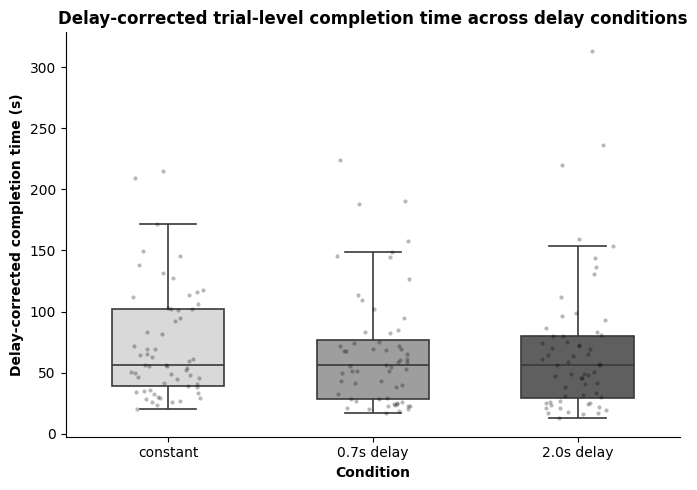

In [25]:
# =======================================================
# PLOT DELAY-CORRECTED COMPLETION TIME BY CONDITION
# =======================================================
# Goal:
# Visualize trial-level completion time across conditions after
# subtracting the gaze-derived delay correction.
#
# Each dot = one valid experimental model trial.
# Boxplot = distribution of delay-corrected trial-level completion times.
#
# No participant averaging.

import matplotlib.pyplot as plt
import seaborn as sns

COND_COLORS = {
    "constant": "#d9d9d9",
    "0.7s delay": "#9e9e9e",
    "2.0s delay": "#5f5f5f"
}

plot_corrected_completion = completion_time_final.copy()

plot_corrected_completion["condition"] = (
    plot_corrected_completion["condition"]
    .astype(str)
)

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=plot_corrected_completion,
    x="condition",
    y="delay_corrected_completion_time_s",
    order=COND_ORDER,
    palette=COND_COLORS,
    showfliers=False,
    width=0.55,
    linewidth=1.2
)

sns.stripplot(
    data=plot_corrected_completion,
    x="condition",
    y="delay_corrected_completion_time_s",
    order=COND_ORDER,
    color="black",
    alpha=0.28,
    size=3,
    jitter=0.18
)

plt.xlabel("Condition", fontweight="bold")
plt.ylabel("Delay-corrected completion time (s)", fontweight="bold")
plt.title(
    "Delay-corrected trial-level completion time across delay conditions",
    fontweight="bold"
)

sns.despine()
plt.tight_layout()
plt.show()

In [26]:
# =======================================================
# CHECK RAW VS DELAY-CORRECTED COMPLETION TIME
# =======================================================

display(
    completion_time_final
    .groupby("condition", observed=False)
    .agg(
        n_trials=("model_name", "nunique"),
        mean_raw_completion_time_s=("raw_completion_time_s", "mean"),
        mean_delay_correction_s=("delay_correction_s", "mean"),
        mean_delay_corrected_completion_time_s=("delay_corrected_completion_time_s", "mean"),
        median_raw_completion_time_s=("raw_completion_time_s", "median"),
        median_delay_corrected_completion_time_s=("delay_corrected_completion_time_s", "median"),
        max_delay_correction_s=("delay_correction_s", "max")
    )
    .round(2)
)

,n_trials,mean_raw_completion_time_s,mean_delay_correction_s,mean_delay_corrected_completion_time_s,median_raw_completion_time_s,median_delay_corrected_completion_time_s,max_delay_correction_s
condition,,,,,,,
0.7s delay,18,72.56,5.95,66.60,63.38,56.24,22.79
2.0s delay,17,80.01,11.37,68.64,65.78,56.04,37.07
constant,18,72.85,0.00,72.85,56.04,56.04,0.00


### Diffrence per trial

In [27]:
# =======================================================
# CHECK DELAY CORRECTION PER TRIAL
# =======================================================

completion_time_final["correction_difference_s"] = (
    completion_time_final["raw_completion_time_s"]
    -
    completion_time_final["delay_corrected_completion_time_s"]
)

display(
    completion_time_final
    .groupby("condition", observed=False)["correction_difference_s"]
    .describe()
    .round(2)
)

,count,mean,std,min,25%,50%,75%,max
condition,,,,,,,,
0.7s delay,60.0,5.95,4.72,0.70,2.24,5.10,8.20,22.79
2.0s delay,60.0,11.37,8.19,1.16,6.00,8.62,14.95,37.07
constant,60.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00


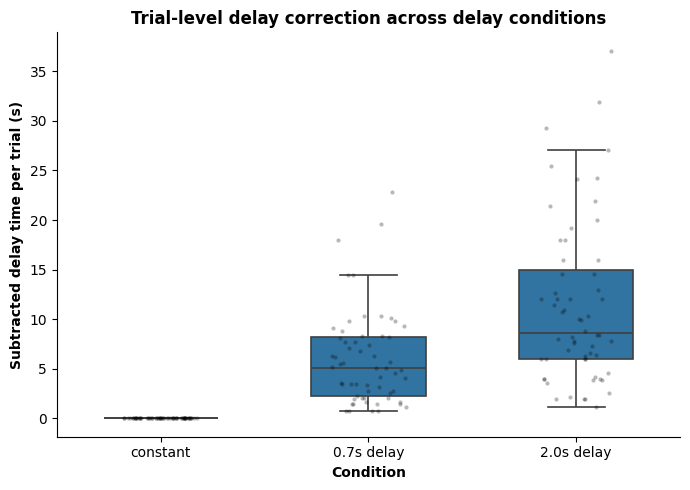

In [28]:
# =======================================================
# PLOT DELAY CORRECTION PER TRIAL BY CONDITION
# =======================================================

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=completion_time_final,
    x="condition",
    y="delay_correction_s",
    order=COND_ORDER,
    showfliers=False,
    width=0.55,
    linewidth=1.2
)

sns.stripplot(
    data=completion_time_final,
    x="condition",
    y="delay_correction_s",
    order=COND_ORDER,
    color="black",
    alpha=0.28,
    size=3,
    jitter=0.18
)

plt.xlabel("Condition", fontweight="bold")
plt.ylabel("Subtracted delay time per trial (s)", fontweight="bold")
plt.title(
    "Trial-level delay correction across delay conditions",
    fontweight="bold"
)

sns.despine()
plt.tight_layout()
plt.show()

In [29]:
# =======================================================
# VERIFY THAT CORRECTION DIFFERENCE EQUALS DELAY CORRECTION
# =======================================================

completion_time_final["correction_difference_s"] = (
    completion_time_final["raw_completion_time_s"]
    -
    completion_time_final["delay_corrected_completion_time_s"]
)

print(
    np.allclose(
        completion_time_final["correction_difference_s"],
        completion_time_final["delay_correction_s"]
    )
)

True


In [30]:
# =======================================================
# INSPECT RAW, SUBTRACTED DELAY, AND CORRECTED TIME
# =======================================================

display(
    completion_time_final[
        [
            "participant_id",
            "model_name",
            "condition",
            "raw_completion_time_s",
            "delay_correction_s",
            "delay_corrected_completion_time_s",
            "n_model_plate_episodes"
        ]
    ]
    .sort_values(["participant_id", "condition", "model_name"])
    .head(50)
)

,participant_id,model_name,condition,raw_completion_time_s,delay_correction_s,delay_corrected_completion_time_s,n_model_plate_episodes
0,1,C1M1F,0.7s delay,70.742,1.679,69.063,3
3,1,C1M4A,0.7s delay,41.620,3.500,38.120,5
8,1,C2M3F,0.7s delay,63.376,4.900,58.476,7
9,1,C2M4A,0.7s delay,63.388,6.755,56.633,10
12,1,C3M1F,0.7s delay,158.795,10.332,148.463,16
15,1,C3M4A,0.7s delay,118.453,9.100,109.353,13
4,1,C1M5F,2.0s delay,33.988,4.000,29.988,2
5,1,C1M6A,2.0s delay,33.976,8.355,25.621,5
6,1,C2M1F,2.0s delay,66.364,10.342,56.022,6
7,1,C2M2A,2.0s delay,78.619,14.555,64.064,8


## Inferential statistik for COMPLETION TIME using Gauß GEE

In [37]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Lineares GEE-Modell mit Gauß-Verteilung und robuster Standardfehlerschätzung
model_completion = smf.gee(
    "raw_completion_time_s ~ C(condition, Treatment(reference='constant'))",
    data=raw_completion_time,
    groups="participant_id",
    family=sm.families.Gaussian(),
    cov_struct=sm.cov_struct.Independence()
)

results_completion = model_completion.fit(cov_type="robust")

# Hypothesen für alle 3 Paarvergleiche
hypotheses = [
    "C(condition, Treatment(reference='constant'))[T.0.7s delay] = 0",                                     # c0: 0.7s vs. constant
    "C(condition, Treatment(reference='constant'))[T.2.0s delay] = 0",                                     # c1: 2.0s vs. constant
    "C(condition, Treatment(reference='constant'))[T.2.0s delay] - C(condition, Treatment(reference='constant'))[T.0.7s delay] = 0"  # c2: 2.0s vs. 0.7s
]

# Output anzeigen
print("==============================================================================")
print("GEE MODEL SUMMARY: RAW TASK COMPLETION TIME (Gaussian)")
print("==============================================================================")
print(results_completion.summary())

print("\n==============================================================================")
print("ALL 3 PAIRWISE COMPARISONS (COMPLETION TIME)")
print("c0 = 0.7s vs. constant | c1 = 2.0s vs. constant | c2 = 2.0s vs. 0.7s")
print("==============================================================================")
print(results_completion.t_test(", ".join(hypotheses)))

GEE MODEL SUMMARY: RAW TASK COMPLETION TIME (Gaussian)
                               GEE Regression Results                               
Dep. Variable:        raw_completion_time_s   No. Observations:                  180
Model:                                  GEE   No. clusters:                       10
Method:                         Generalized   Min. cluster size:                  18
                       Estimating Equations   Max. cluster size:                  18
Family:                            Gaussian   Mean cluster size:                18.0
Dependence structure:          Independence   Num. iterations:                     2
Date:                      Wed, 22 Jul 2026   Scale:                        2871.552
Covariance type:                     robust   Time:                         01:19:51
                                                                  coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------

##